In [1]:
# MLflow experiment tracking setup (DagsHub-hosted tracking server)
from dotenv import load_dotenv
load_dotenv("../.env")

import mlflow
import mlflow.sklearn

mlflow.set_experiment("transaction-classifier")

<Experiment: artifact_location='mlflow-artifacts:/83f248ce78b84147bf60246593e1a087', creation_time=1783091276343, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1783091276343, lifecycle_stage='active', name='transaction-classifier', tags={}, trace_location=None, workspace='default'>

In [2]:
#load the data
# We load the data and split it into train, validation and test sets. The test set is kept separate for final evaluation after model selection and tuning is done on the train and validation sets.

import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("../data/raw/train_transactions.csv")
test_df = pd.read_csv("../data/raw/test_transactions.csv")

X_train_full = train_df['transaction_text']
y_train_full = train_df['category']

X_test = test_df['transaction_text']
y_test = test_df['category']

#split train into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)


print(f"Train: {len(X_train)}, Val: {len(X_val)}, test: {len(X_test)}")


Train: 4000, Val: 1000, test: 1000


In [3]:
#clean the text by removing amounts, transaction ids, and other numbers. This will help the model focus on the actual text rather than specific numbers which may not generalize well.

import re

def clean_text(text):
    text = re.sub(r'INR\s*\d+', '', text)
    text = re.sub(r'TXN+\w+', '', text)
    text = re.sub(r'\d+', '', text)
    return text.strip().lower()

X_train_clean = X_train.apply(clean_text)
X_val_clean = X_val.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

#what's left after cleaning?
print(X_train_clean.head(10).to_list())

['online payment', 'mobile phone purchase', 'irctc train ticket', 'wazixr crypto purch', 'pizza hut order', 'broadband recharge', 'pantaloons purch', 'youtube premium suu', 'housekeeping svc payemnt', 'hostel fee payment']


In [4]:
#tfidf vectorization and logistic regression model training
#convert the cleaned text into numerical features using TF-IDF vectorization and then train a logistic regression model on the training data. We will evaluate the model on the validation set to see how well it performs.

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, f1_score

TFIDF_MAX_FEATURES = 5000
TFIDF_NGRAM_RANGE = (1, 2)

tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_val_tfidf = tfidf.transform(X_val_clean)

with mlflow.start_run(run_name="logistic_regression"):
    mlflow.log_params({
        "model_type": "LogisticRegression",
        "max_iter": 1000,
        "tfidf_max_features": TFIDF_MAX_FEATURES,
        "tfidf_ngram_range": str(TFIDF_NGRAM_RANGE),
        "dataset": "train_transactions.csv",
    })

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_val_tfidf)

    val_accuracy = accuracy_score(y_val, y_pred)
    val_f1_macro = f1_score(y_val, y_pred, average="macro")
    mlflow.log_metrics({
        "val_accuracy": val_accuracy,
        "val_f1_macro": val_f1_macro,
    })

    print("Logistic Regression:")
    print(classification_report(y_val, y_pred))

Logistic Regression:
               precision    recall  f1-score   support

    education       0.80      0.66      0.72       111
          emi       0.90      0.75      0.82       111
entertainment       0.73      0.73      0.73       111
         food       0.81      0.73      0.77       111
   healthcare       0.65      0.89      0.75       111
   investment       0.81      0.79      0.80       112
     shopping       0.67      0.67      0.67       111
       travel       0.76      0.92      0.83       111
    utilities       0.81      0.73      0.77       111

     accuracy                           0.76      1000
    macro avg       0.77      0.76      0.76      1000
 weighted avg       0.77      0.76      0.76      1000

🏃 View run logistic_regression at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0/runs/433df4deff774240920d789e4f88324d
🧪 View experiment at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0


In [5]:
#random forest for comparison
# trains a random forest classifier to see if it performs better than logistic regression on this task. Random forests can capture more complex relationships in the data, but they may also be more prone to overfitting, especially with high-dimensional data like text features.
from sklearn.ensemble import RandomForestClassifier

N_ESTIMATORS = 100

with mlflow.start_run(run_name="random_forest"):
    mlflow.log_params({
        "model_type": "RandomForestClassifier",
        "n_estimators": N_ESTIMATORS,
        "tfidf_max_features": TFIDF_MAX_FEATURES,
        "tfidf_ngram_range": str(TFIDF_NGRAM_RANGE),
        "dataset": "train_transactions.csv",
    })

    model_rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=42)
    model_rf.fit(X_train_tfidf, y_train)
    y_pred_rf = model_rf.predict(X_val_tfidf)

    val_accuracy_rf = accuracy_score(y_val, y_pred_rf)
    val_f1_macro_rf = f1_score(y_val, y_pred_rf, average="macro")
    mlflow.log_metrics({
        "val_accuracy": val_accuracy_rf,
        "val_f1_macro": val_f1_macro_rf,
    })

    print("Random Forest:")
    print(classification_report(y_val, y_pred_rf))

Random Forest:
               precision    recall  f1-score   support

    education       0.74      0.67      0.70       111
          emi       0.87      0.77      0.81       111
entertainment       0.66      0.68      0.67       111
         food       0.85      0.70      0.77       111
   healthcare       0.66      0.85      0.74       111
   investment       0.83      0.81      0.82       112
     shopping       0.66      0.67      0.66       111
       travel       0.73      0.86      0.79       111
    utilities       0.81      0.74      0.77       111

     accuracy                           0.75      1000
    macro avg       0.76      0.75      0.75      1000
 weighted avg       0.76      0.75      0.75      1000

🏃 View run random_forest at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0/runs/3af4a975ee7a4ae29350b898bf03c8dc
🧪 View experiment at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0


In [6]:
#select the best model based on validation performance
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_val, y_pred)
acc_rf = accuracy_score(y_val, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

if acc_rf >= acc_lr:
    print("Random Forest performs better, or as good as Logistic Regression. Selecting Random Forest for final evaluation.")
    best_model = model_rf
    best_name = "Random Forest"
else:
    print("Logistic Regression performs better. Selecting Logistic Regression for final evaluation.")
    best_model = model
    best_name = "Logistic Regression"



Logistic Regression Accuracy: 0.7620
Random Forest Accuracy: 0.7490
Logistic Regression performs better. Selecting Logistic Regression for final evaluation.


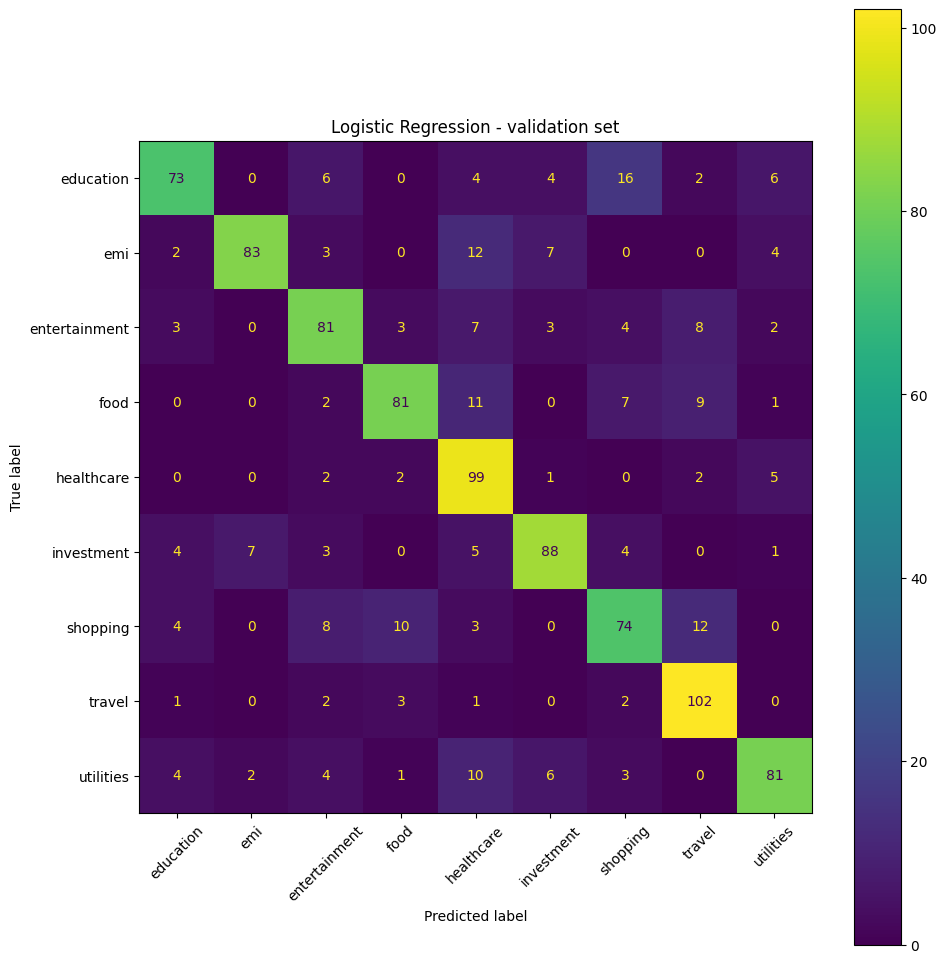

In [7]:
#confusion matrix for best model 
# The confusion matrix provides a visual representation of the model's performance, showing how many instances were correctly classified and where the model made mistakes. This can help identify specific categories that the model struggles with and guide further improvements.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, xticks_rotation=45)
plt.title(f"{best_name} - validation set")
plt.tight_layout()
plt.show()


In [8]:
# Final evaluation on test set, with MLflow logging + model registration for the winning model
import joblib
import os

X_test_tfidf = tfidf.transform(X_test_clean)
y_test_pred = best_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")
report_dict = classification_report(y_test, y_test_pred, output_dict=True)
per_class_f1 = {
    f"test_f1_{label}": scores["f1-score"]
    for label, scores in report_dict.items()
    if label in set(y_test.unique())
}

with mlflow.start_run(run_name=f"final_{best_name.lower().replace(' ', '_')}"):
    mlflow.log_params({
        "model_type": best_name,
        "tfidf_max_features": TFIDF_MAX_FEATURES,
        "tfidf_ngram_range": str(TFIDF_NGRAM_RANGE),
        "dataset": "test_transactions.csv",
    })
    mlflow.log_metrics({
        "test_accuracy": test_accuracy,
        "test_f1_macro": test_f1_macro,
        **per_class_f1,
    })

    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        registered_model_name="transaction-classifier",
    )

    tfidf_artifact_path = "tfidf_vectorizer.joblib"
    joblib.dump(tfidf, tfidf_artifact_path)
    mlflow.log_artifact(tfidf_artifact_path, artifact_path="vectorizer")
    os.remove(tfidf_artifact_path)

print(f"Final evaluation on test set ({best_name}):")
print(classification_report(y_test, y_test_pred))

2026/07/07 21:30:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/07 21:30:43 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp8mbd7q70/model/model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 
2026/07/07 21:30:43 WARNING mlflow.utils.requirements_utils: Encountered an unexpected error (MetadataNotFound('No package metadata was found.')) while detecting model dependency mismatches. Set logging level to DEBUG to see the full traceback.
Registered model 'transaction-classifier' already exists. Creating a new version of this model...
2026/07/07 21:30:47 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: transaction-classifier, version 2
Created version '2' of model 'transaction-classifier'.


🏃 View run final_logistic_regression at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0/runs/66d05a6eeafc47b6bfa1bf8c53aa0bd8
🧪 View experiment at: https://dagshub.com/frgr3618/transaction-classifier.mlflow/#/experiments/0
Final evaluation on test set (Logistic Regression):
               precision    recall  f1-score   support

    education       0.81      0.78      0.80       111
          emi       0.87      0.81      0.84       111
entertainment       0.85      0.68      0.76       111
         food       0.79      0.75      0.77       111
   healthcare       0.68      0.86      0.76       111
   investment       0.88      0.77      0.82       111
     shopping       0.72      0.75      0.73       112
       travel       0.75      0.90      0.82       111
    utilities       0.82      0.79      0.81       111

     accuracy                           0.79      1000
    macro avg       0.80      0.79      0.79      1000
 weighted avg       0.80      0.79 

## Robustness check: sensitivity to the train/validation split

The validation accuracy can come out a few points away from the test accuracy (e.g. 0.76 vs 0.79), which looks surprising at first — a held-out test set should not outperform validation. Before trusting the results, we verify that such a gap is just **sampling noise on 1,000-row evaluation sets** rather than a bug or data leakage: the standard error of an accuracy estimate around 0.77 with n=1000 is ~1.3 points, so two different 1,000-row samples can easily disagree by ±3 points.

To confirm, we refit the exact same pipeline with several different random train/validation splits and watch how much each number moves. If the spread of validation scores across seeds covers the val-vs-test gap, and the test score stays stable regardless of the split, the results are steady and the gap is explained by sampling variation — the direction (test ≥ val) also rules out overfitting model selection to the validation set.

Note: this check uses its own variable names (`tfidf_check`, `model_check`) so it cannot overwrite the fitted `tfidf` / `best_model` that are saved for deployment below.

In [9]:
# Refit the same pipeline across several train/val splits to show the results are steady.
# Deliberately uses separate variable names (tfidf_check, model_check) so nothing here
# touches the fitted `tfidf`/`best_model` that get saved for deployment below.
X_full_clean = X_train_full.apply(clean_text)

print("Validation / test accuracy across different random splits (only the split seed changes):")
val_accs, test_accs = [], []
for seed in [42, 1, 7, 99, 123]:
    Xtr, Xv, ytr, yv = train_test_split(
        X_full_clean, y_train_full, test_size=0.2, random_state=seed, stratify=y_train_full
    )
    tfidf_check = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE)
    model_check = LogisticRegression(max_iter=1000, random_state=42)
    model_check.fit(tfidf_check.fit_transform(Xtr), ytr)

    val_acc = accuracy_score(yv, model_check.predict(tfidf_check.transform(Xv)))
    test_acc = accuracy_score(y_test, model_check.predict(tfidf_check.transform(X_test_clean)))
    val_accs.append(val_acc)
    test_accs.append(test_acc)
    print(f"  split seed {seed:3d}: val={val_acc:.3f}  test={test_acc:.3f}")

import numpy as np
print(f"\nval  accuracy: mean={np.mean(val_accs):.3f}, spread={max(val_accs)-min(val_accs):.3f}")
print(f"test accuracy: mean={np.mean(test_accs):.3f}, spread={max(test_accs)-min(test_accs):.3f}")
print("\nConclusion: validation moves by ~±1.5 points depending on the split alone, while test")
print("stays stable -- so a small val-vs-test gap is sampling noise, not leakage or a bug.")

Validation / test accuracy across different random splits (only the split seed changes):
  split seed  42: val=0.762  test=0.789
  split seed   1: val=0.762  test=0.788
  split seed   7: val=0.785  test=0.790
  split seed  99: val=0.776  test=0.796
  split seed 123: val=0.792  test=0.793

val  accuracy: mean=0.775, spread=0.030
test accuracy: mean=0.791, spread=0.008

Conclusion: validation moves by ~±1.5 points depending on the split alone, while test
stays stable -- so a small val-vs-test gap is sampling noise, not leakage or a bug.


In [10]:
#save model and vectorizer for deployment
import joblib
import os

os.makedirs("../src", exist_ok=True)
joblib.dump(best_model, "../src/model.joblib")
joblib.dump(tfidf, "../src/tfidf.joblib")

print("Model and vectorizer saved to /src for deployment.")


Model and vectorizer saved to /src for deployment.
